In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("stock_data.csv")
df

,Date,Open,High,Low,Close,Volume
0,2026-01-02,101.09,103.37,100.08,102.04,89377.0
1,2026-01-05,101.05,101.99,99.91,100.58,88404.0
2,2026-01-06,102.41,103.15,99.47,101.36,94045.0
3,2026-01-07,105.35,108.05,103.53,106.87,72352.0
4,2026-01-08,105.13,109.88,104.24,107.49,79790.0
5,2026-01-09,104.91,108.22,103.42,107.07,81919.0
6,2026-01-12,107.95,109.49,104.84,106.57,45600.0
7,2026-01-13,109.53,111.44,107.88,NaN,69124.0
8,2026-01-14,108.89,111.08,107.60,109.85,67643.0
9,2026-01-15,110.07,114.76,109.21,112.32,80764.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    50 non-null     object 
 1   Open    49 non-null     float64
 2   High    49 non-null     float64
 3   Low     50 non-null     float64
 4   Close   49 non-null     float64
 5   Volume  49 non-null     float64
dtypes: float64(5), object(1)
memory usage: 2.5+ KB


In [4]:
df.head()

,Date,Open,High,Low,Close,Volume
0,2026-01-02,101.09,103.37,100.08,102.04,89377.0
1,2026-01-05,101.05,101.99,99.91,100.58,88404.0
2,2026-01-06,102.41,103.15,99.47,101.36,94045.0
3,2026-01-07,105.35,108.05,103.53,106.87,72352.0
4,2026-01-08,105.13,109.88,104.24,107.49,79790.0


In [5]:
df.shape

(50, 6)

In [6]:
df.isnull().sum()

Date      0
Open      1
High      1
Low       0
Close     1
Volume    1
dtype: int64

In [8]:
df["Date"]=pd.to_datetime(df["Date"])
df.dtypes

Date      datetime64[ns]
Open             float64
High             float64
Low              float64
Close            float64
Volume           float64
dtype: object

In [9]:
df["Close"]=df["Close"].ffill()

In [11]:
df["Open"]=df["Open"].bfill()

In [13]:
df["Volume"]=df["Volume"].ffill()

In [14]:
df["High"]=df["High"].ffill()

In [15]:
df.isnull().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(3)

In [17]:
df=df.sort_values("Date")
df

,Date,Open,High,Low,Close,Volume
0,2026-01-02,101.09,103.37,100.08,102.04,89377.0
1,2026-01-05,101.05,101.99,99.91,100.58,88404.0
2,2026-01-06,102.41,103.15,99.47,101.36,94045.0
3,2026-01-07,105.35,108.05,103.53,106.87,72352.0
4,2026-01-08,105.13,109.88,104.24,107.49,79790.0
5,2026-01-09,104.91,108.22,103.42,107.07,81919.0
20,2026-01-09,104.91,108.22,103.42,107.07,81919.0
6,2026-01-12,107.95,109.49,104.84,106.57,45600.0
7,2026-01-13,109.53,111.44,107.88,106.57,69124.0
8,2026-01-14,108.89,111.08,107.60,109.85,67643.0


In [19]:
df["MA_5"]=df["Close"].rolling(5).mean()
df["MA_20"]=df["Close"].rolling(20).mean()
df

,Date,Open,High,Low,Close,Volume,MA_5,MA_20
0,2026-01-02,101.09,103.37,100.08,102.04,89377.0,NaN,NaN
1,2026-01-05,101.05,101.99,99.91,100.58,88404.0,NaN,NaN
2,2026-01-06,102.41,103.15,99.47,101.36,94045.0,NaN,NaN
3,2026-01-07,105.35,108.05,103.53,106.87,72352.0,NaN,NaN
4,2026-01-08,105.13,109.88,104.24,107.49,79790.0,103.668,NaN
5,2026-01-09,104.91,108.22,103.42,107.07,81919.0,104.674,NaN
20,2026-01-09,104.91,108.22,103.42,107.07,81919.0,105.972,NaN
6,2026-01-12,107.95,109.49,104.84,106.57,45600.0,107.014,NaN
7,2026-01-13,109.53,111.44,107.88,106.57,69124.0,106.954,NaN
8,2026-01-14,108.89,111.08,107.60,109.85,67643.0,107.426,NaN


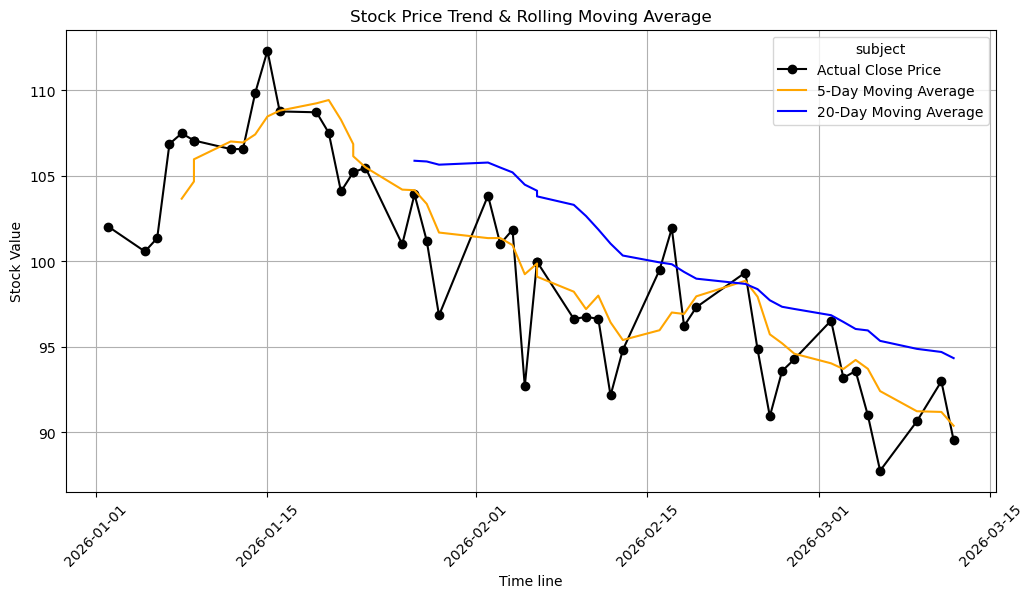

In [21]:
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Close"],label='Actual Close Price', color='black',marker='o')
plt.plot(df["Date"], df["MA_5"],label='5-Day Moving Average',color='orange')
plt.plot(df["Date"], df["MA_20"],label='20-Day Moving Average',color='blue')   

plt.title('Stock Price Trend & Rolling Moving Average')
plt.xlabel('Time line')
plt.ylabel('Stock Value')
plt.grid(True)
plt.legend(title="subject")
plt.xticks(rotation=45)
plt.show()